In [1]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# 1. ĐỊNH TUYẾN DỮ LIỆU
data_dir = '/kaggle/input/datasets/akashshingha850/mrl-eye-dataset/data' 

# Augmentation 
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),          
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms),
    'val': datasets.ImageFolder(os.path.join(data_dir, 'val'), test_transforms),
    'test': datasets.ImageFolder(os.path.join(data_dir, 'test'), test_transforms)
}

batch_size = 64
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=(x == 'train'), num_workers=2)
    for x in ['train', 'val', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"📊 Dữ liệu: Train ({dataset_sizes['train']}) | Val ({dataset_sizes['val']}) | Test ({dataset_sizes['test']})")
print(f"🏷️ Classes: {class_names}")

📊 Dữ liệu: Train (50937) | Val (16980) | Test (16981)
🏷️ Classes: ['awake', 'sleepy']


In [3]:
# 2. KHỞI TẠO MOBILENET-V2 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🚀 Khởi tạo MobileNetV2 trên {device}...")

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Đóng băng phần thân (Feature Extractor)
for param in model.features.parameters():
    param.requires_grad = False

# Sửa lại lớp phân loại cuối cùng (Classifier) cho 2 class: awake và sleepy
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_ftrs, len(class_names))
)

model = model.to(device)


🚀 Khởi tạo MobileNetV2 trên cuda...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 121MB/s]


In [4]:
# 3. THIẾT LẬP TỐI ƯU & HUẤN LUYỆN
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.classifier.parameters(), lr=0.001, weight_decay=1e-4)
num_epochs = 20
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

patience = 5
epochs_no_improve = 0

print("\n🔥 BẮT ĐẦU HUẤN LUYỆN...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 15)

    # Mở khóa các lớp cuối của features (Gradual Unfreezing) ở Epoch 5 để học sâu hơn
    if epoch == 5:
        print("🔓 Mở khóa 3 block cuối của MobileNetV2 để tinh chỉnh...")
        for param in model.features[-3:].parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(num_epochs - 5))

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0.0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data).float()

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects / dataset_sizes[phase]

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())

        print(f"{phase.capitalize()} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

        # Early Stopping dựa trên tập Validation
        if phase == 'val':
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                print(f"🌟 Kỷ lục mới! (Val Acc: {best_acc:.4f})")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"\n🛑 Kích hoạt Early Stopping tại Epoch {epoch+1}")
                    break
                    
    if epochs_no_improve >= patience:
        break
    scheduler.step()
    print()

time_elapsed = time.time() - start_time
print(f"✅ Hoàn tất trong {time_elapsed // 60:.0f} phút {time_elapsed % 60:.0f} giây")

# Lưu mô hình
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), '/kaggle/working/best_eye_state_mobilenetv2.pt')
print("💾 Đã lưu 'best_eye_state_mobilenetv2.pt'")


🔥 BẮT ĐẦU HUẤN LUYỆN...
Epoch 1/20
---------------
Train | Loss: 0.2568 | Accuracy: 0.8986
Val | Loss: 0.2773 | Accuracy: 0.8835
🌟 Kỷ lục mới! (Val Acc: 0.8835)

Epoch 2/20
---------------
Train | Loss: 0.2308 | Accuracy: 0.9084
Val | Loss: 0.2104 | Accuracy: 0.9191
🌟 Kỷ lục mới! (Val Acc: 0.9191)

Epoch 3/20
---------------
Train | Loss: 0.2297 | Accuracy: 0.9100
Val | Loss: 0.2123 | Accuracy: 0.9172

Epoch 4/20
---------------
Train | Loss: 0.2329 | Accuracy: 0.9075
Val | Loss: 0.2025 | Accuracy: 0.9229
🌟 Kỷ lục mới! (Val Acc: 0.9229)

Epoch 5/20
---------------
Train | Loss: 0.2261 | Accuracy: 0.9113
Val | Loss: 0.1866 | Accuracy: 0.9313
🌟 Kỷ lục mới! (Val Acc: 0.9313)

Epoch 6/20
---------------
🔓 Mở khóa 3 block cuối của MobileNetV2 để tinh chỉnh...
Train | Loss: 0.1048 | Accuracy: 0.9629
Val | Loss: 0.1063 | Accuracy: 0.9600
🌟 Kỷ lục mới! (Val Acc: 0.9600)

Epoch 7/20
---------------
Train | Loss: 0.0699 | Accuracy: 0.9745
Val | Loss: 0.0684 | Accuracy: 0.9753
🌟 Kỷ lục mới! (Val

In [5]:
# 4. KIỂM TRA TRÊN TẬP TEST 
model.eval()
test_corrects = 0
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data).float()

test_acc = test_corrects / dataset_sizes['test']
print(f"🏆Test Accuracy: {test_acc:.4f}")

🏆Test Accuracy: 0.9816


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

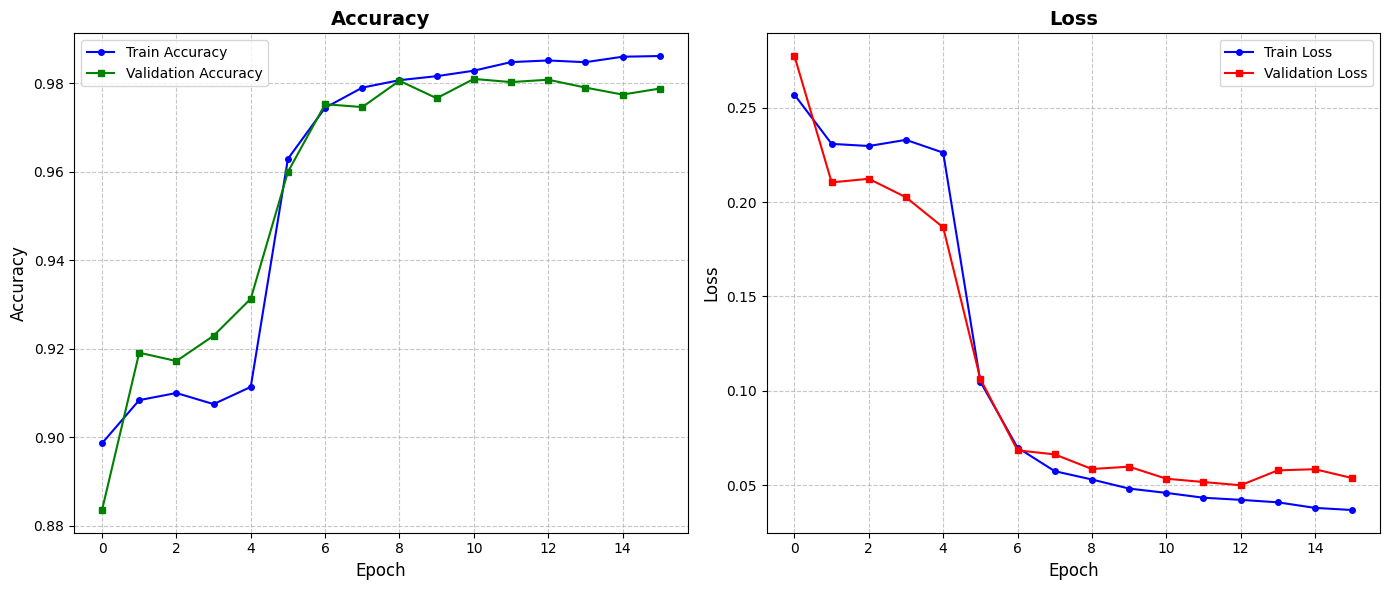

📸 Đã lưu biểu đồ huấn luyện tại: /kaggle/working/eye_state_training_chart.png


In [7]:
# 5. VẼ BIỂU ĐỒ 
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue', marker='o', markersize=4)
plt.plot(history['val_acc'], label='Validation Accuracy', color='green', marker='s', markersize=4)
plt.title('Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o', markersize=4)
plt.plot(history['val_loss'], label='Validation Loss', color='red', marker='s', markersize=4)
plt.title('Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/kaggle/working/eye_state_training_chart.png', dpi=300)
plt.show()
print("📸 Đã lưu biểu đồ huấn luyện tại: /kaggle/working/eye_state_training_chart.png")

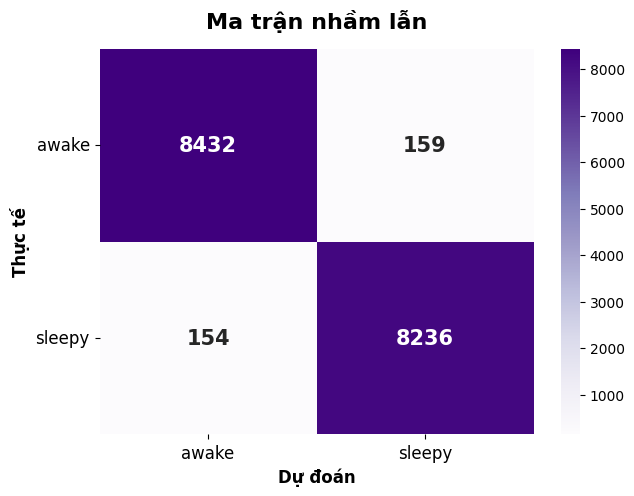

📸 Đã lưu Ma trận nhầm lẫn tại: /kaggle/working/eye_state_confusion_matrix.png


In [8]:
# 6. VẼ MA TRẬN NHẦM LẪN 
model.load_state_dict(torch.load('/kaggle/working/best_eye_state_mobilenetv2.pt'))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Tính toán Ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 15, "weight": "bold"})

plt.title('Ma trận nhầm lẫn', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Dự đoán', fontsize=12, fontweight='bold')
plt.ylabel('Thực tế', fontsize=12, fontweight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

plt.savefig('/kaggle/working/eye_state_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("📸 Đã lưu Ma trận nhầm lẫn tại: /kaggle/working/eye_state_confusion_matrix.png")